# What is Fisher information?

## Maximum Likelihood Estimation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
TRUE_MU = 85.0
KNOWN_SIGMA = 12.0

First, we determine the population mean and standard deviation.

In [3]:
api_logs = np.random.normal(loc=TRUE_MU, scale=KNOWN_SIGMA, size=5)
api_logs_50 = np.random.normal(loc=TRUE_MU, scale=KNOWN_SIGMA, size=50)
print(f"Recorded API response times (ms) (n=5): {np.round(api_logs, 2)}")
print(f"Recorded API response times (ms) (n=50): {np.round(api_logs, 2)}")

Recorded API response times (ms) (n=5): [88.18 82.84 67.66 89.71 82.77]
Recorded API response times (ms) (n=50): [88.18 82.84 67.66 89.71 82.77]


We draw two samples from our population with sample sizes of 5 and 50. In these lines, we have also indicated that our population is normally distributed.

In [4]:
mle_mu = np.mean(api_logs)
mle_mu_50 = np.mean(api_logs_50)
print(f"Sample mean (MLE of mu) (n=5) {mle_mu}")
print(f"Sample mean (MLE of mu) (n=50): {mle_mu_50}")

Sample mean (MLE of mu) (n=5) 82.23333581201817
Sample mean (MLE of mu) (n=50): 84.68763602522723


As we learned in the section on maximum likelihood estimators, we know that the sample mean is the maximum likelihood estimator for the mean of population, therefore, we define the maximum likelihood estimators for the population mean of both samples as the sample means.

In [5]:
x_axis = np.linspace(40, 130, 500)

In [6]:
pdf_curve = norm.pdf(x_axis, loc=mle_mu, scale=KNOWN_SIGMA)
pdf_curve_50 = norm.pdf(x_axis, loc=mle_mu_50, scale=KNOWN_SIGMA)

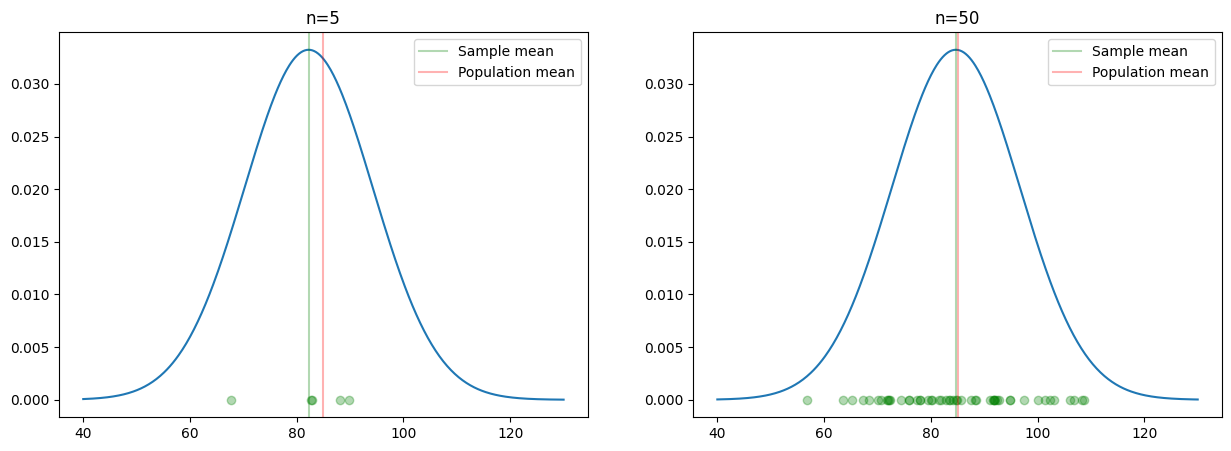

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].set_title("n=5")
axes[0].plot(x_axis, pdf_curve)
axes[0].axvline(mle_mu, label="Sample mean", color="green", alpha=0.3)
axes[0].axvline(TRUE_MU, label="Population mean", color="red", alpha=0.3)
axes[0].scatter(api_logs, np.zeros_like(api_logs), color="green", alpha=0.3)
axes[0].legend()
axes[1].set_title("n=50")
axes[1].plot(x_axis, pdf_curve_50)
axes[1].axvline(mle_mu_50, label="Sample mean", color="green", alpha=0.3)
axes[1].axvline(TRUE_MU, label="Population mean", color="red", alpha=0.3)
axes[1].scatter(api_logs_50, np.zeros_like(api_logs_50), color="green", alpha=0.3)
axes[1].legend()
plt.show()

What we’ll learn about Fisher information will also give us some insight into sample size. But as we can see here, an increase in sample size does indeed indicate that we’re getting closer to the population mean.

Now let’s generate 500 linearly spaced guesses for the population mean, ranging from 0 to 150.

In [8]:
mu_guesses = np.linspace(0, 150, 500)

In [9]:
api_logs

array([88.18432853, 82.8445581 , 67.65938512, 89.71318752, 82.76521979])

The mathematical equivalents of the relevant lines are as follows (for the likelihood function)

$$
\begin{aligned}
\verb|norm.pdf(api_logs, ...)| : f(x_i \mid \mu, \sigma) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left( -\frac{(x_i - \mu)^2}{2\sigma^2} \right) \\
\verb|np.prod(...)| : L(\mu) = \prod_{i=1}^{5} f(x_i \mid \mu, \sigma) \\
\verb|raw_likelihoods| = \begin{bmatrix} L(\mu_1) \\ L(\mu_2) \\ \vdots \\ L(\mu_{500}) \end{bmatrix}
\end{aligned}
$$

In [10]:
raw_likelihoods = np.array(
    [np.prod(norm.pdf(api_logs, loc=guess, scale=KNOWN_SIGMA)) for guess in mu_guesses]
)
raw_likelihoods

array([1.45480053e-59, 3.42675554e-59, 8.04637338e-59, 1.88345229e-58,
       4.39487421e-58, 1.02229364e-57, 2.37051254e-57, 5.47956695e-57,
       1.26266343e-56, 2.90045648e-56, 6.64174945e-56, 1.51612849e-55,
       3.45006210e-55, 7.82627676e-55, 1.76978649e-54, 3.98955020e-54,
       8.96529073e-54, 2.00836297e-53, 4.48494807e-53, 9.98412515e-53,
       2.21564409e-52, 4.90148147e-52, 1.08091643e-51, 2.37626162e-51,
       5.20755391e-51, 1.13765526e-50, 2.47756451e-50, 5.37869164e-50,
       1.16403411e-49, 2.51126273e-49, 5.40077372e-49, 1.15786305e-48,
       2.47454750e-48, 5.27195603e-48, 1.11965738e-47, 2.37047785e-47,
       5.00292554e-47, 1.05256654e-46, 2.20755976e-46, 4.61543630e-46,
       9.61945436e-46, 1.99859824e-45, 4.13940525e-45, 8.54648978e-45,
       1.75903708e-44, 3.60910564e-44, 7.38178819e-44, 1.50508473e-43,
       3.05912839e-43, 6.19828932e-43, 1.25193958e-42, 2.52076452e-42,
       5.05962781e-42, 1.01237695e-41, 2.01931147e-41, 4.01514988e-41,
      

And for the log-likelihood function, we have the following.

$$
\begin{aligned}
\verb|np.sum(...)| : l(\mu) = \sum_{i=1}^{5} \ln\big(f(x_i \mid \mu, \sigma)\big) \\ 
\verb|log_likelihoods| = \begin{bmatrix} l(\mu_1) \\ l(\mu_2) \\ \vdots \\ l(\mu_{500}) \end{bmatrix}
\end{aligned}
$$

In [11]:
log_likelihoods = np.array(
    [
        np.sum(norm.logpdf(api_logs, loc=guess, scale=KNOWN_SIGMA))
        for guess in mu_guesses
    ]
)
log_likelihoods

array([-135.47765169, -134.62090658, -133.76729901, -132.91682898,
       -132.06949648, -131.22530153, -130.38424411, -129.54632423,
       -128.71154188, -127.87989708, -127.05138981, -126.22602008,
       -125.40378788, -124.58469323, -123.76873611, -122.95591653,
       -122.14623449, -121.33968998, -120.53628301, -119.73601358,
       -118.93888169, -118.14488733, -117.35403052, -116.56631124,
       -115.7817295 , -115.00028529, -114.22197862, -113.44680949,
       -112.6747779 , -111.90588385, -111.14012733, -110.37750835,
       -109.61802691, -108.86168301, -108.10847664, -107.35840781,
       -106.61147652, -105.86768277, -105.12702655, -104.38950787,
       -103.65512673, -102.92388313, -102.19577707, -101.47080854,
       -100.74897755, -100.0302841 ,  -99.31472818,  -98.6023098 ,
        -97.89302896,  -97.18688566,  -96.4838799 ,  -95.78401167,
        -95.08728098,  -94.39368783,  -93.70323221,  -93.01591414,
        -92.3317336 ,  -91.6506906 ,  -90.97278513,  -90.29801

In [12]:
log_likelihoods_50 = np.array(
    [
        np.sum(norm.logpdf(api_logs_50, loc=guess, scale=KNOWN_SIGMA))
        for guess in mu_guesses
    ]
)

Since we are primarily interested in the log-likelihood function, we calculated the results of the log-likelihood function for all our $\mu$ guesses for our 50 variable sample as well.

For our sample consisting of 5 items, the likelihood and log-likelihood functions produce the following plots for all mu guesses.

<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_353167/2815302883.py:6: SyntaxWarning: invalid escape sequence '\p'
  axes[0].set_ylabel("Probability Product $L(\\theta)=\prod_{i=1}^{n} f(x_i| \\theta)$")
/tmp/ipykernel_353167/2815302883.py:13: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_ylabel("Sum of Log-Probabilities $\sum_{i=1}^{n}ln(f(x_i|\\theta))$")


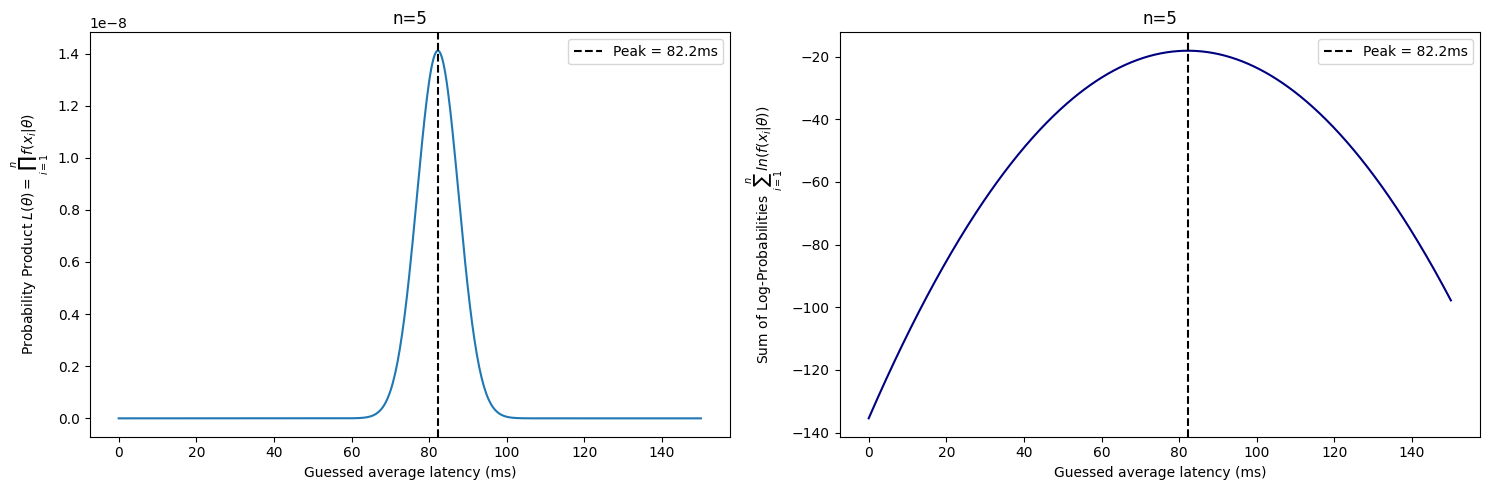

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].set_title("n=5")
axes[0].plot(mu_guesses, raw_likelihoods)
axes[0].axvline(mle_mu, color="black", linestyle="--", label=f"Peak = {mle_mu:.1f}ms")
axes[0].set_xlabel("Guessed average latency (ms)")
axes[0].set_ylabel("Probability Product $L(\\theta)=\prod_{i=1}^{n} f(x_i| \\theta)$")
axes[0].legend()

axes[1].set_title("n=5")
axes[1].plot(mu_guesses, log_likelihoods, color="navy")
axes[1].axvline(mle_mu, color="black", linestyle="--", label=f"Peak = {mle_mu:.1f}ms")
axes[1].set_xlabel("Guessed average latency (ms)")
axes[1].set_ylabel("Sum of Log-Probabilities $\sum_{i=1}^{n}ln(f(x_i|\\theta))$")
axes[1].legend()
plt.tight_layout()
plt.show()

Since the values on the y-axis here do not represent a probability density function, they are not particularly meaningful. What we should focus on is where the peaks of these functions lie.

The peak points of the graphs of the two functions also correspond to the sample mean, which is something we already know from MLE notes.

<>:9: SyntaxWarning: invalid escape sequence '\e'
<>:9: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_353167/1411469695.py:9: SyntaxWarning: invalid escape sequence '\e'
  label=f"$\ell$ when n=50",


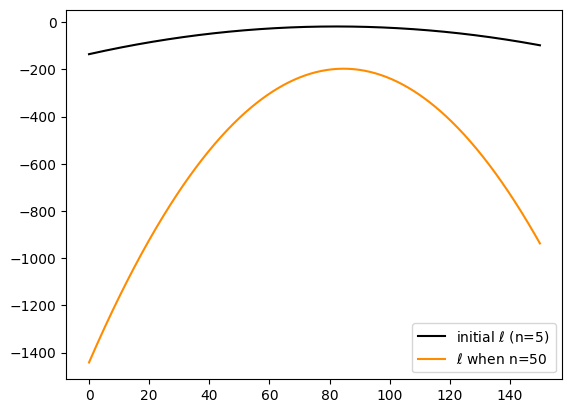

In [14]:
fig, ax = plt.subplots()

plt.plot(mu_guesses, log_likelihoods, color="black", label="initial $\\ell$ (n=5)")
plt.plot(
    mu_guesses,
    log_likelihoods_50,
    color="darkorange",
    linestyle="-",
    label=f"$\ell$ when n=50",
)
plt.legend()
plt.show()

Here we also see that while the peak of the 5-element sample is not very sharp, the peak of the 50-element sample is quite sharp. It makes sense to place more confidence in the estimate with the sharper peak. For our sample of 50 elements, this sharp peak formed by the $\mu$ guesses entered into our log-likelihood function indicates high Fisher information, but how?

## Fisher information

In the previous steps, we created samples containing 5 and 50 elements only once. Here, however, we created a large number of samples with 50 elements (in practice, an infinite number of times, provided the number of digits after the decimal point is not too many).

In [15]:
sample_size_50_universes = np.random.normal(
    loc=TRUE_MU, scale=KNOWN_SIGMA, size=(5000, 50)
)

And we know that the sample mean is the maximum likelihood estimator of the population mean, so we collected the means of all the samples we have into a new array.

In [16]:
means_of_universes = np.mean(sample_size_50_universes, axis=1)

Now let’s calculate the variance of these sample means we’ve obtained or in other words, let’s calculate the variance of the sampling distribution of the sample mean.

In [17]:
brute_force_variance = np.var(means_of_universes)

If the sample means we obtain from the samples differ significantly from one another (variance), this leads us to conclude that our sample size is insufficient to make reliable inferences, and that the sample mean, while an unbiased estimator, is not a very reliable estimator.

So a high variance indicates that we have little information, while a low variance indicates that we have a lot of information. Now, keep this in mind.

In [18]:
fisher_information = 50 / KNOWN_SIGMA**2

The Fisher information of the entire sample with known variance is $\frac{n}{\sigma^2}$.

In [19]:
print(f"Inverse variance of the estimator (sample mean): {1/brute_force_variance}")
print(f"Thoretical Fisher information: {fisher_information}")

Inverse variance of the estimator (sample mean): 0.33874312882165736
Thoretical Fisher information: 0.3472222222222222


We know that the sampling distribution of the sample mean has a variance of $\frac{\sigma^2}{n}$. The inverse of the variance of our estimator is nearly equal to the Fisher information of this distribution, which essentially indicates how much information we have. This is because Cramér-Rao Lower Bound states that variance of any unbiased estimator must be greater or equal to the inverse of the Fisher information.